<a href="https://colab.research.google.com/github/tamyressilvazz/machine-learning-p04/blob/main/Exercicio01_tbs5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Carregar e preparar os dados**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

import pydotplus #pip install pydotplus
import numpy as np

In [ ]:
df = pd.read_csv('/content/drive/My Drive/datasets/metrics.csv')

df.head()

,n_versions,n_fixes,n_refact,n_authors,lines_added,max_lin_add,avg_lin_add,lines_rem,max_lin_rem,avg_lin_rem,code_churn,max_code_churn,avg_code_churn,age,weighted_age,class
0,65,4,0,8,608,158,935.385,566,158,870.769,42,15,646.154,350.571,630.609,NO_BUG
1,2,0,0,2,10,10,5.000,0,0,0.000,10,10,5.000,117.714,0.000,NO_BUG
2,120,10,0,12,1361,99,113.417,768,77,6.400,593,66,494.167,238.429,104.204,BUG
3,28,4,0,5,138,39,492.857,123,39,439.286,15,23,535.714,367.000,112.678,NO_BUG
4,93,17,0,8,1870,684,201.075,1881,692,202.258,-11,18,-11.828,367.000,549.702,NO_BUG


O resultado apresenta as primeiras instâncias do conjunto de dados de bugs, contendo métricas relacionadas ao histórico de modificações dos arquivos de software, como número de versões, linhas adicionadas/removidas, churn de código e número de autores. A coluna class indica a variável alvo do problema, classificando cada arquivo como BUG ou NO_BUG, que será utilizada posteriormente para treinar os modelos de aprendizado de máquina.

In [ ]:
X = df.iloc[:, :-1]   # todas as colunas menos a última
y = df.iloc[:, -1]    # última coluna (classe)
print(X)
print(y)

     n_versions  n_fixes  n_refact  n_authors  lines_added  max_lin_add  \
0            65        4         0          8          608          158   
1             2        0         0          2           10           10   
2           120       10         0         12         1361           99   
3            28        4         0          5          138           39   
4            93       17         0          8         1870          684   
..          ...      ...       ...        ...          ...          ...   
992          58       14         0          6         1017          246   
993          35        5         0          9          322           48   
994          34        5         0          7          690          119   
995           3        3         0          1           32           27   
996          51        8         0         10         2071          317   

     avg_lin_add  lines_rem  max_lin_rem  avg_lin_rem  code_churn  \
0        935.385        566   

O resultado apresenta a separação do conjunto de dados em variáveis de entrada (X) e variável alvo (y). A primeira tabela mostra as 15 métricas do software utilizadas como atributos do modelo, como número de versões, correções, autores, linhas adicionadas/removidas, churn de código e idade do arquivo. Essas variáveis serão usadas para treinar o modelo de classificação.

A segunda saída mostra a variável alvo (class), que indica se cada instância do conjunto de dados corresponde a BUG ou NO_BUG. O dataset possui 997 registros, que serão utilizados posteriormente para separar os dados em treinamento e teste e construir os modelos de aprendizado de máquina.

**2. Separar conjunto de treino e teste**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])

Y = df['class']

# Separando os dados em treinamento(75%) e teste(25%)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

class_counts = Y.value_counts()

class_percentages = (class_counts / len(df)) * 100

print(class_percentages)


class
NO_BUG    79.338014
BUG       20.661986
Name: count, dtype: float64


Observa-se que aproximadamente 79,34% das instâncias são classificadas como NO_BUG e 20,66% como BUG. Isso indica que o dataset é desbalanceado, pois a maioria dos exemplos pertence à classe NO_BUG

In [ ]:
X_train.head()

,n_versions,n_fixes,n_refact,n_authors,lines_added,max_lin_add,avg_lin_add,lines_rem,max_lin_rem,avg_lin_rem,code_churn,max_code_churn,avg_code_churn,age,weighted_age
642,23,6,0,5,225,83,978.261,221,83,96.087,4,6,173.913,367.000,794.641
928,26,6,0,5,243,56,934.615,99,14,380.769,144,55,553.846,190.714,540.406
97,45,15,0,7,813,187,180.667,414,187,9.200,399,93,886.667,333.143,984.973
894,124,14,0,5,4604,1294,37.129,4049,1294,326.532,555,170,447.581,367.000,541.314
948,20,8,1,6,203,69,10.150,64,15,3.200,139,69,6.950,222.714,254.849


As primeiras instâncias do conjunto de dados de treinamento (X_train) após a divisão entre dados de treino e teste. A tabela mostra apenas as variáveis preditoras (features) utilizadas pelo modelo, como número de versões, correções, autores, linhas adicionadas/removidas, churn de código e idade do arquivo. A coluna class não aparece porque ela foi separada anteriormente como variável alvo. Esses dados serão utilizados para treinar os modelos de classificação, permitindo que aprendam padrões que ajudam a prever a ocorrência de bugs.

**3. Criar árvore de decisão com profundidade 2**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion = 'gini',max_depth = 2, min_samples_leaf = 50)

dt.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=50)

**4. Visualizar a árvore**

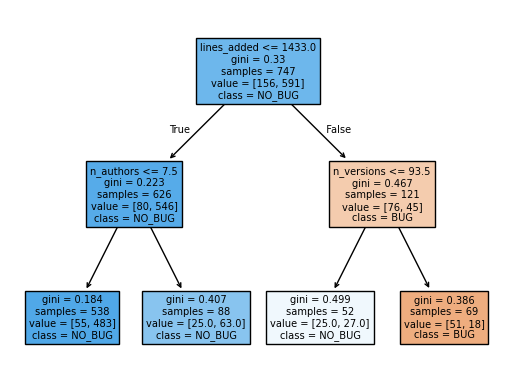

In [ ]:
from sklearn import tree


tree.plot_tree(dt, feature_names = X.columns, class_names=["BUG", "NO_BUG"], filled = True);


**Que variáveis foram mais importantes para classificação de bugs?**
A árvore de decisão indica que as variáveis mais importantes para a classificação de bugs foram lines_added, n_authors e n_versions.

A variável lines_added aparece no nó raiz da árvore, sendo o primeiro critério utilizado para dividir os dados, o que indica que ela possui a maior importância para distinguir entre arquivos com BUG e NO_BUG. Em seguida, as variáveis n_authors (número de autores que modificaram o arquivo) e n_versions (número de versões do arquivo) são utilizadas nos nós seguintes para refinar a classificação.

Isso sugere que arquivos com maior quantidade de linhas adicionadas, maior número de versões ou modificados por mais desenvolvedores tendem a apresentar maior probabilidade de conter bugs.

**5. Descobrir quais variáveis foram mais importantes**

In [ ]:
from sklearn.metrics import accuracy_score

Yhat_train = dt.predict(X_train)

print("Acurácia dos dados de treinamento   : ", accuracy_score(Y_train,Yhat_train))

Yhat_test = dt.predict(X_test)

print("Acurácia dos dados de teste  : ", accuracy_score(Y_test,Yhat_test))

Acurácia dos dados de treinamento   :  0.8353413654618473
Acurácia dos dados de teste  :  0.868


A acurácia do modelo de árvore de decisão nos conjuntos de treinamento e teste. A acurácia obtida foi de aproximadamente 83,53% no conjunto de treinamento e 86,8% no conjunto de teste. Esses valores indicam que o modelo conseguiu classificar corretamente a maior parte das instâncias e apresenta um desempenho semelhante nos dois conjuntos, sugerindo que o modelo possui boa capacidade de generalização para dados não vistos.

In [ ]:
from sklearn.metrics import accuracy_score

for depth in [4,5,6]:
    for leaf in [5, 30, 60]:

        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )

        model.fit(X_train, Y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(Y_test, pred)

        # Combinações das acurácias
        print("depth:", depth,
              "leaf:", leaf,
              "accuracy:", acc)

depth: 4 leaf: 5 accuracy: 0.848
depth: 4 leaf: 30 accuracy: 0.868
depth: 4 leaf: 60 accuracy: 0.828
depth: 5 leaf: 5 accuracy: 0.792
depth: 5 leaf: 30 accuracy: 0.868
depth: 5 leaf: 60 accuracy: 0.828
depth: 6 leaf: 5 accuracy: 0.82
depth: 6 leaf: 30 accuracy: 0.868
depth: 6 leaf: 60 accuracy: 0.828


Observa-se que a maior acurácia obtida no conjunto de teste foi 0.868, alcançada em várias configurações (por exemplo, depth = 4, 5 ou 6 com leaf = 30). Já valores menores de leaf ou maiores profundidades podem reduzir a acurácia, possivelmente devido ao overfitting. Assim, os resultados indicam que configurações com cerca de 30 exemplos por nó folha apresentaram melhor desempenho para esse conjunto de dados.

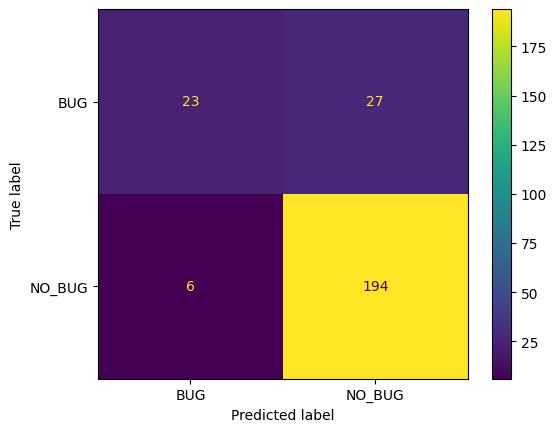

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Displaying the confusion matrix

cm = confusion_matrix(Y_test, Yhat_test, labels=dt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt.classes_)

disp.plot()

plt.show()

O modelo é muito bom para identificar arquivos sem bug

194 acertos contra apenas 6 erros.

O modelo tem mais dificuldade para detectar bugs

Só detectou 23, mas deixou passar 27.

Isso acontece porque o dataset é desbalanceado

Cerca de 79% dos exemplos são NO_BUG e apenas 21% são BUG.

Então o modelo tende a prever mais NO_BUG.
O modelo tem boa acurácia geral, mas não é tão eficiente para encontrar bugs, pois deixa vários passar.

**6. Treinar Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 200, max_features = 3)

rf.fit(X_train, Y_train)

RandomForestClassifier(max_features=3, n_estimators=200)

In [ ]:
from sklearn.metrics import accuracy_score

Yhat = rf.predict(X_test)

print("Acurácia dos dados de teste  : ", accuracy_score(Y_test,Yhat))

Acurácia dos dados de teste  :  0.852


O modelo conseguiu classificar corretamente aproximadamente 85% das instâncias do conjunto de teste. Esse valor permite comparar o desempenho do Random Forest com o modelo de árvore de decisão, avaliando qual abordagem apresenta melhor capacidade de classificação para o problema de detecção de bugs.

**8. Comparar os modelos**

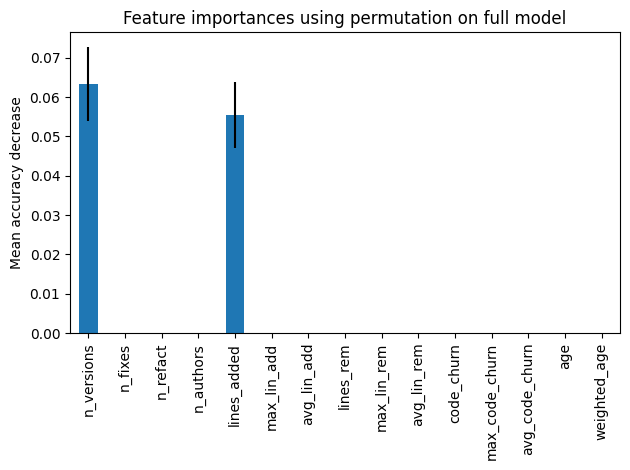

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(dt, X_test, Y_test,n_repeats=100, random_state=2)

forest_importances = pd.Series(result.importances_mean, index=X.columns)

fig, ax = plt.subplots()

forest_importances.plot.bar(yerr=result.importances_std, ax=ax)

ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

As variáveis n_versions e lines_added possuem maior importância, pois causam a maior redução na acurácia quando alteradas. Isso indica que essas métricas têm maior influência na previsão de bugs. As demais variáveis apresentam impacto muito menor na performance do modelo, sugerindo que contribuem menos para a classificação.

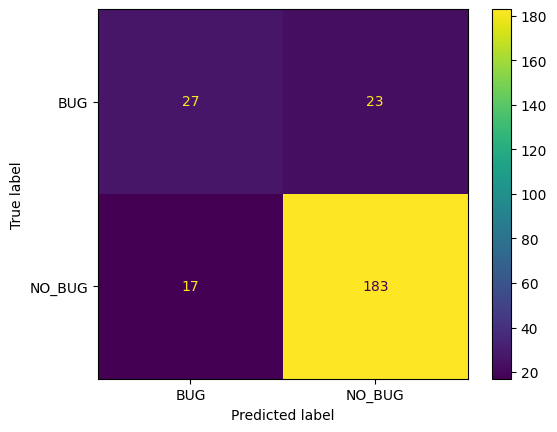

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Displaying the confusion matrix

cm = confusion_matrix(Y_test, Yhat, labels=rf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf.classes_)

disp.plot()

plt.show()

Observa-se que 27 arquivos com BUG foram corretamente classificados como BUG, enquanto 23 arquivos com BUG foram classificados incorretamente como NO_BUG.

Para a classe NO_BUG, 183 instâncias foram corretamente classificadas, enquanto 17 foram classificadas incorretamente como BUG.

Esses resultados indicam que o modelo consegue identificar corretamente a maioria dos arquivos sem bug, mas ainda apresenta algumas dificuldades para detectar todos os casos de BUG, gerando alguns erros de classificação. Ainda assim, o modelo demonstra um bom desempenho geral, classificando corretamente a maior parte das instâncias do conjunto de teste.

**Que modelo (árvores de decisão ou Random Forest) obteve o melhor resultado?**

A árvore de decisão apresentou melhor desempenho do que o modelo Random Forest. A árvore de decisão alcançou uma acurácia de aproximadamente 86,8% no conjunto de teste, enquanto o Random Forest obteve cerca de 85,2%.

Apesar do Random Forest ser geralmente um modelo mais robusto, neste conjunto de dados específico a árvore de decisão simples apresentou uma acurácia ligeiramente maior, indicando melhor desempenho para a tarefa de classificação de bugs.